# 🏆 Meta dei tornei ufficiali — Pokémon TCG Standard (limitlesstcg.com)

Analisi del **metagame reale** del gioco di carte fisico nei tornei ufficiali, formato **Standard**,
usando i dati aggregati di [limitlesstcg.com](https://limitlesstcg.com/decks).

I dati vengono **scaricati live** e messi in cache locale (`.cache/`) per non ripetere le richieste
a ogni run. Il modulo `meta_utils` gestisce i certificati TLS (utile dietro proxy aziendali).

Indice:
1. Classifica degli archetipi (share del meta)
2. Concentrazione del meta (top-tier vs coda "rogue")
3. Core cards degli archetipi di punta
4. Carte più giocate nel meta (pesate per share)
5. Ponte con il card pool della competizione


In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
import meta_utils as mu

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 10, "figure.autolayout": True})
PAL = plt.get_cmap("tab10").colors
FMT = "standard"          # cambia in 'expanded' per l'altro formato
TOP_N_ARCH = 12           # quanti archetipi approfondire nelle sezioni 3-4

def save(fig, name):
    fig.savefig(mu.FIG_DIR / f"02_{name}.png", bbox_inches="tight", dpi=130)
    print("salvato:", (mu.FIG_DIR / f"02_{name}.png").name)

print("TLS:", mu.enable_tls())

[meta_utils] TLS mode: truststore
TLS: truststore


## 1. Classifica degli archetipi
Ogni archetipo con i punti accumulati nei tornei e la sua **share** (quota del metagame).

Archetipi in classifica: 25


,rank,archetype,deck_id,points,share_pct
0,1,Dragapult ex,284,25753,9.36
1,2,Gardevoir ex,255,21434,7.79
2,3,Charizard ex,264,14530,5.28
3,4,Lugia Archeops,247,13045,4.74
4,5,Gholdengo ex,267,12373,4.50
5,6,Lost Zone Box,241,10760,3.91
6,7,Arceus VSTAR,212,9894,3.59
7,8,Raging Bolt ex,280,9485,3.45
8,9,Mew Genesect Fusion Strike,211,8247,3.00
9,10,Zoroark GX,47,7070,2.57


salvato: 02_archetypes_share.png


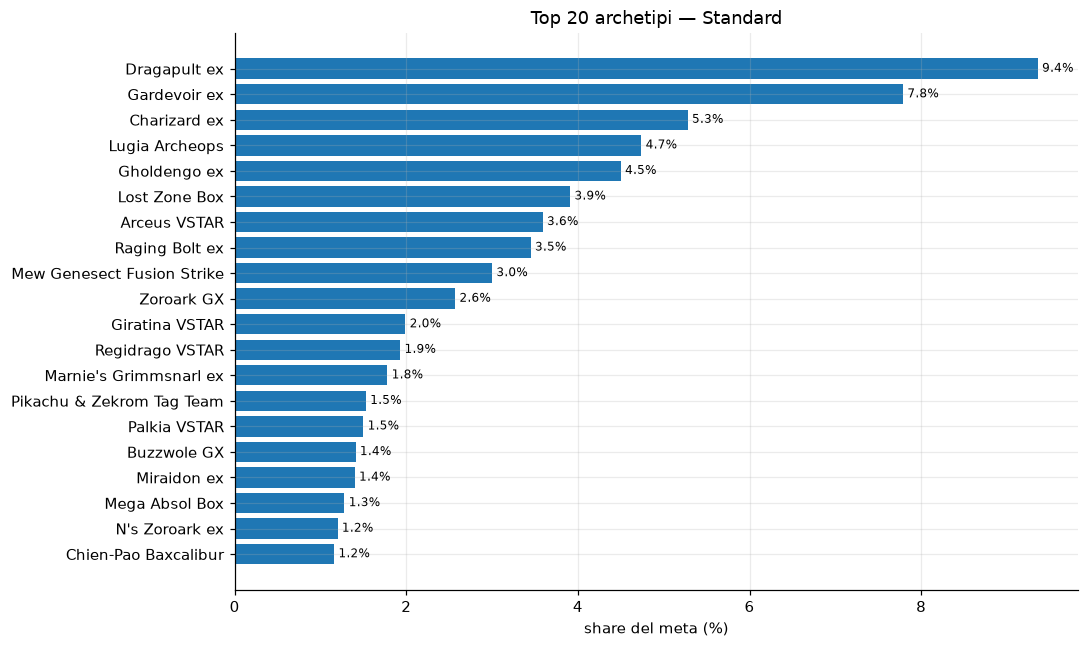

In [2]:
meta = mu.fetch_meta_table(FMT)
print(f"Archetipi in classifica: {len(meta)}")
display(meta.head(15))

fig, ax = plt.subplots(figsize=(10, 6))
top = meta.head(20).iloc[::-1]
ax.barh(top["archetype"], top["share_pct"], color=PAL[0])
ax.set_xlabel("share del meta (%)"); ax.set_title(f"Top 20 archetipi — Standard")
for i, v in enumerate(top["share_pct"]):
    ax.text(v + .05, i, f"{v:.1f}%", va="center", fontsize=8)
save(fig, "archetypes_share"); plt.show()

## 2. Concentrazione del meta
Quanto è "top-heavy" il formato? La curva cumulata mostra quanta parte del meta è coperta dai
primi N archetipi. Un meta concentrato = pochi mazzi dominanti; una coda lunga = tante scelte valide.

salvato: 02_meta_concentration.png


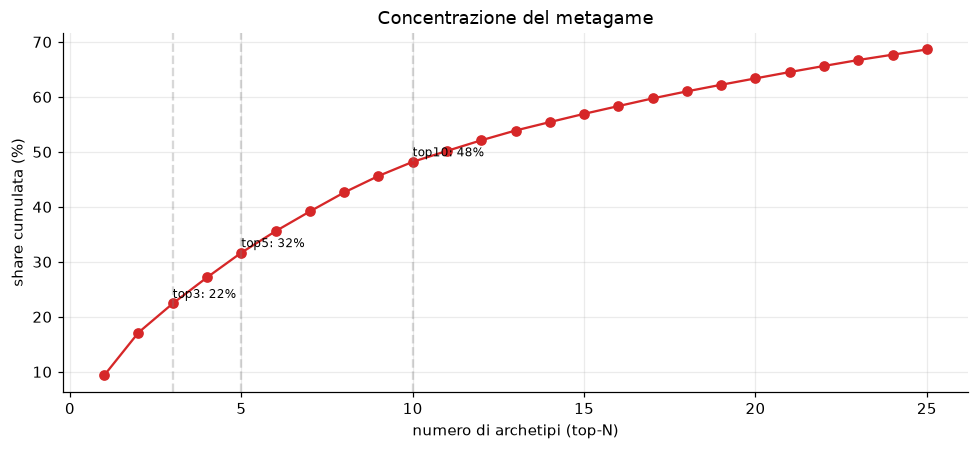

Top 3 archetipi = 22.4% del meta
Top 5 archetipi = 31.7% del meta
Top 10 archetipi = 48.2% del meta


In [3]:
m = meta.sort_values("share_pct", ascending=False).reset_index(drop=True)
cum = m["share_pct"].cumsum()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(range(1, len(m)+1), cum, marker="o", color=PAL[3])
ax.set_xlabel("numero di archetipi (top-N)"); ax.set_ylabel("share cumulata (%)")
ax.set_title("Concentrazione del metagame")
for k in (3, 5, 10):
    if k <= len(cum):
        ax.axvline(k, ls="--", alpha=.3, color="grey")
        ax.text(k, cum.iloc[k-1]+1, f"top{k}: {cum.iloc[k-1]:.0f}%", fontsize=8)
save(fig, "meta_concentration"); plt.show()

print(f"Top 3 archetipi = {cum.iloc[2]:.1f}% del meta")
print(f"Top 5 archetipi = {cum.iloc[4]:.1f}% del meta")
print(f"Top 10 archetipi = {cum.iloc[9]:.1f}% del meta")

## 3. Core cards degli archetipi di punta
Per ogni archetipo top scarichiamo le **core card** (le carte staple, con numero di copie e % di
liste che le includono). I nomi vengono risolti da set+numero e messi in cache.

⏳ Al primo run scarica diverse pagine (con pausa gentile tra le richieste); i run successivi usano la cache.

In [4]:
frames = []
top_arch = meta.dropna(subset=["deck_id"]).head(TOP_N_ARCH)
for _, r in top_arch.iterrows():
    core = mu.fetch_deck_core(r["deck_id"], FMT)
    if core.empty:
        continue
    core["archetype"] = r["archetype"]
    core["arch_share"] = r["share_pct"]
    frames.append(core)
    print(f"  {r['archetype']:<28} core cards: {len(core)}")

core_all = pd.concat(frames, ignore_index=True)
# risolvi i nomi (cache su disco: veloce dai run successivi)
uniq = core_all[["set","number"]].drop_duplicates()
print(f"Risolvo {len(uniq)} nomi carta...")
name_map = {}
for _, r in uniq.iterrows():
    name_map[(r["set"], r["number"])] = mu.resolve_card_name(r["set"], r["number"])
core_all["card"] = core_all.apply(lambda r: name_map[(r["set"], r["number"])], axis=1)
print("Fatto. Righe core totali:", len(core_all))
core_all.head()

  Dragapult ex                 core cards: 19


  Gardevoir ex                 core cards: 25


  Charizard ex                 core cards: 12


  Lugia Archeops               core cards: 19


  Gholdengo ex                 core cards: 15


...

  Raging Bolt ex               core cards: 23


  Mew Genesect Fusion Strike   core cards: 17


  Regidrago VSTAR              core cards: 20
Risolvo 123 nomi carta...


Fatto. Righe core totali: 184


,set,number,copies,inclusion_pct,card_url,archetype,arch_share,card
0,TWM,128,4,99.80,https://limitlesstcg.com/cards/TWM/128,Dragapult ex,9.36,Dreepy
1,TWM,129,4,99.80,https://limitlesstcg.com/cards/TWM/129,Dragapult ex,9.36,Drakloak
2,TWM,130,2,100.00,https://limitlesstcg.com/cards/TWM/130,Dragapult ex,9.36,Dragapult ex
3,ASC,16,1,99.59,https://limitlesstcg.com/cards/ASC/16,Dragapult ex,9.36,Budew
4,ASC,142,1,97.96,https://limitlesstcg.com/cards/ASC/142,Dragapult ex,9.36,Fezandipiti ex


In [5]:
# Esempio: core deck di un archetipo specifico
arch = top_arch.iloc[0]["archetype"]
one = core_all[core_all["archetype"] == arch].sort_values("inclusion_pct", ascending=False)
print(f"Core cards di «{arch}»:")
display(one[["card","set","number","copies","inclusion_pct"]].reset_index(drop=True))

Core cards di «Dragapult ex»:


,card,set,number,copies,inclusion_pct
0,Dragapult ex,TWM,130,2,100.00
1,Ultra Ball,MEG,131,3,100.00
2,Dreepy,TWM,128,4,99.80
3,Drakloak,TWM,129,4,99.80
4,Munkidori,TWM,95,1,99.80
5,Darkness Energy,MEE,7,1,99.80
6,Night Stretcher,ASC,196,2,99.80
7,Buddy-Buddy Poffin,TEF,144,4,99.59
8,Psychic Energy,MEE,5,3,99.59
9,Lillie's Determination,MEG,119,4,99.59


## 4. Carte più giocate nel meta (pesate per share)
Aggreghiamo le carte su tutti gli archetipi top. Ogni carta è pesata dalla **share dell'archetipo**
in cui compare × copie × % di inclusione, così le staple dei mazzi popolari salgono in cima.
È l'equivalente "meta reale" della domanda *quali sono le carte più forti/giocate*.

salvato: 02_most_played_cards.png


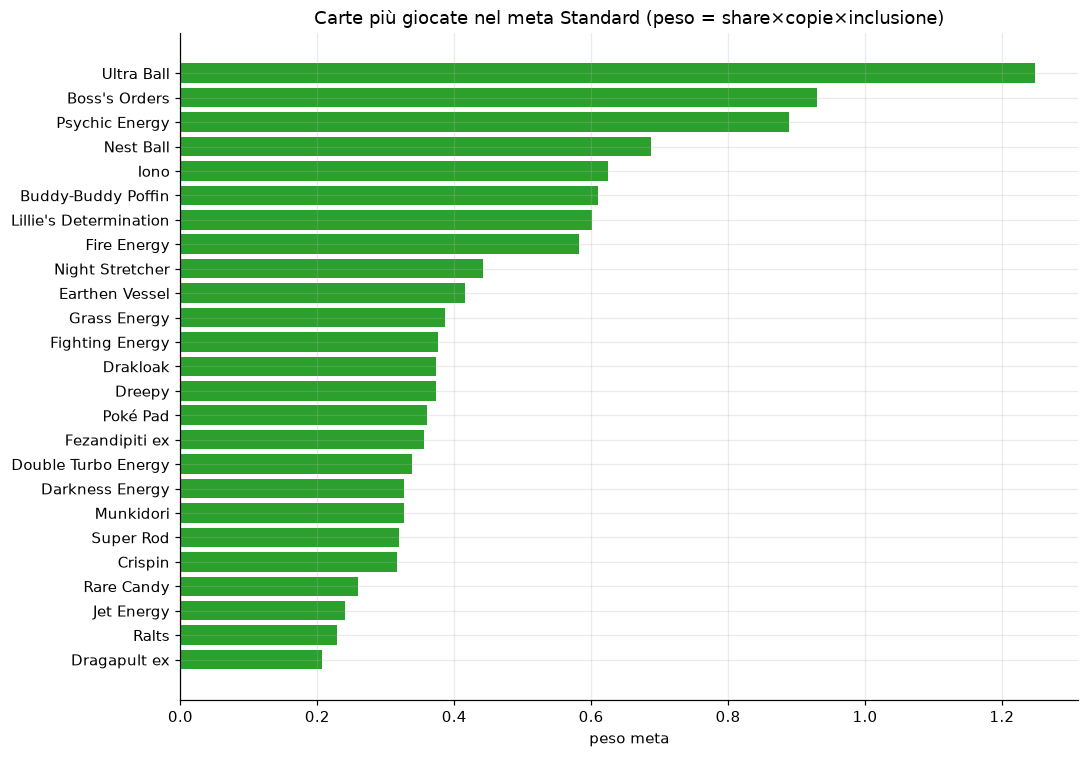

— Carte 'techiche' più diffuse tra archetipi diversi —


,card,peso,archetipi,copie_medie
0,Boss's Orders,0.929644,9,2.222222
1,Ultra Ball,1.248733,7,3.857143
2,Fezandipiti ex,0.355723,7,1.000000
3,Nest Ball,0.687831,6,3.000000
4,Iono,0.625064,6,2.166667
5,Night Stretcher,0.442709,4,1.750000
6,Super Rod,0.319756,4,2.000000
7,Psychic Energy,0.889133,3,4.000000
8,Buddy-Buddy Poffin,0.609465,3,3.000000
9,Fire Energy,0.581687,3,3.333333


Salvati CSV in C:\Users\mbasc\workspaces\Pokemon-AI-Battle\meta_analysis\output\data


In [6]:
core_all["weight"] = (core_all["arch_share"]/100.0) * core_all["copies"].fillna(0) * (core_all["inclusion_pct"].fillna(0)/100.0)
played = (core_all.groupby("card")
          .agg(peso=("weight","sum"),
               archetipi=("archetype","nunique"),
               copie_medie=("copies","mean"))
          .sort_values("peso", ascending=False).reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
top = played.head(25).iloc[::-1]
ax.barh(top["card"], top["peso"], color=PAL[2])
ax.set_title("Carte più giocate nel meta Standard (peso = share×copie×inclusione)")
ax.set_xlabel("peso meta");
save(fig, "most_played_cards"); plt.show()

print("— Carte 'techiche' più diffuse tra archetipi diversi —")
display(played.sort_values(["archetipi","peso"], ascending=False).head(15).reset_index(drop=True))
played.to_csv(mu.DATA_DIR / "limitless_most_played_cards.csv", index=False)
meta.to_csv(mu.DATA_DIR / "limitless_meta_standard.csv", index=False)
print("Salvati CSV in", mu.DATA_DIR)

## 5. Ponte con il card pool della competizione
Quante delle carte più giocate nel meta reale esistono anche nel card pool della competizione?
Un match per **nome** (approssimativo: nomi/localizzazioni possono differire) dà un'idea di quanto
il meta ufficiale sia trasferibile alla nostra AI battle.

In [7]:
try:
    comp = mu.cards_unique(mu.load_cards())
    comp_names = set(comp["Card Name"].str.strip())
    top_played = played.head(40).copy()
    top_played["nel_pool_competizione"] = top_played["card"].apply(
        lambda n: any(n.split(" - ")[0].strip().lower() == cn.lower() or
                      n.split(" - ")[0].strip().lower() in cn.lower() for cn in comp_names))
    hit = top_played["nel_pool_competizione"].mean()*100
    print(f"Delle top 40 carte del meta reale, ~{hit:.0f}% trova un nome compatibile nel pool competizione.")
    display(top_played[["card","peso","nel_pool_competizione"]].head(25).reset_index(drop=True))
except Exception as e:
    print("Bridge non disponibile:", e)

Delle top 40 carte del meta reale, ~57% trova un nome compatibile nel pool competizione.

,card,peso,nel_pool_competizione
0,Ultra Ball,1.248733,True
1,Boss's Orders,0.929644,False
2,Psychic Energy,0.889133,True
3,Nest Ball,0.687831,False
4,Iono,0.625064,True
5,Buddy-Buddy Poffin,0.609465,True
6,Lillie's Determination,0.600582,True
7,Fire Energy,0.581687,False
8,Night Stretcher,0.442709,True
9,Earthen Vessel,0.415001,False


---
### Note su fonti e riproducibilità
- **Fonte:** limitlesstcg.com — pagine `/decks`, `/decks/<id>`, `/cards/<set>/<num>`. Dati aggregati
  dai risultati dei tornei ufficiali.
- **Cache:** le richieste sono salvate in `meta_analysis/.cache/`. Cancella la cartella per forzare
  un refresh completo.
- **Formato:** imposta `FMT = "expanded"` nella cella di setup per analizzare l'Expanded.
- **Cortesia:** c'è un throttle tra le richieste; non abbassarlo per rispetto del sito.